# B+ Tree vs Brute Force Report

This notebook summarizes benchmark results and displays all performance charts from `database/performance_results_jpgs`.

In [1]:
from pathlib import Path
import json
import math

import matplotlib.pyplot as plt
from IPython.display import display, Markdown

In [2]:
module_a_dir = Path.cwd()
if module_a_dir.name == "database":
    module_a_dir = module_a_dir.parent
elif (module_a_dir / "Module_A").exists():
    module_a_dir = module_a_dir / "Module_A"

db_dir = module_a_dir / "database"
viz_dir = db_dir / "visualizations"
jpg_dir = db_dir / "performance_results_jpgs"

display(Markdown(f"**JPG charts folder:** `{jpg_dir}`"))
display(Markdown(f"Available JPG files: **{len(list(jpg_dir.glob('*.jpg')))}**"))

**JPG charts folder:** `c:\Users\Eshwar\Documents\maaps\College_Social_Media_DB\Module_A\database\performance_results_jpgs`

Available JPG files: **8**

In [3]:
json_path = viz_dir / "benchmark_results.json"
with open(json_path, "r", encoding="utf-8") as f:
    data = json.load(f)

display(Markdown("## Benchmark Configuration"))
display(data["config"])

rows = data["results"]
display(Markdown("## Key Results (seconds)"))
print(f"{'Size':>6} | {'B+ Insert':>10} | {'Brute Insert':>12} | {'B+ Search':>10} | {'Brute Search':>12}")
print('-' * 68)
for r in rows:
    size = r['size']
    b = r['bplustree']
    bf = r['bruteforce']
    print(f"{size:6d} | {b['insert_time_sec']:10.6f} | {bf['insert_time_sec']:12.6f} | {b['search_time_sec']:10.6f} | {bf['search_time_sec']:12.6f}")

avg_insert_speedup = sum(r['bruteforce']['insert_time_sec'] / max(r['bplustree']['insert_time_sec'], 1e-12) for r in rows) / len(rows)
avg_search_speedup = sum(r['bruteforce']['search_time_sec'] / max(r['bplustree']['search_time_sec'], 1e-12) for r in rows) / len(rows)
display(Markdown(f"Average insert speedup (Brute/B+): **{avg_insert_speedup:.2f}x**"))
display(Markdown(f"Average search speedup (Brute/B+): **{avg_search_speedup:.2f}x**"))

## Benchmark Configuration

{'sizes': [100, 1100, 2100, 3100, 4100, 5100, 6100, 7100, 8100, 9100],
 'seed': 42,
 'bplustree_order': 4}

## Key Results (seconds)

  Size |  B+ Insert | Brute Insert |  B+ Search | Brute Search
--------------------------------------------------------------------
   100 |   0.000252 |     0.000139 |   0.000018 |     0.000054
  1100 |   0.001578 |     0.017536 |   0.000194 |     0.005153
  2100 |   0.003107 |     0.062112 |   0.000372 |     0.019398
  3100 |   0.004848 |     0.141593 |   0.000678 |     0.040964
  4100 |   0.006847 |     0.246260 |   0.000903 |     0.072824
  5100 |   0.008141 |     0.375975 |   0.001061 |     0.116361
  6100 |   0.010475 |     0.547401 |   0.001389 |     0.155883
  7100 |   0.012588 |     0.739131 |   0.001644 |     0.204919
  8100 |   0.013440 |     0.977596 |   0.001752 |     0.266823
  9100 |   0.015758 |     1.209123 |   0.002189 |     0.338800


Average insert speedup (Brute/B+): **40.35x**

Average search speedup (Brute/B+): **87.66x**

## Performance Charts

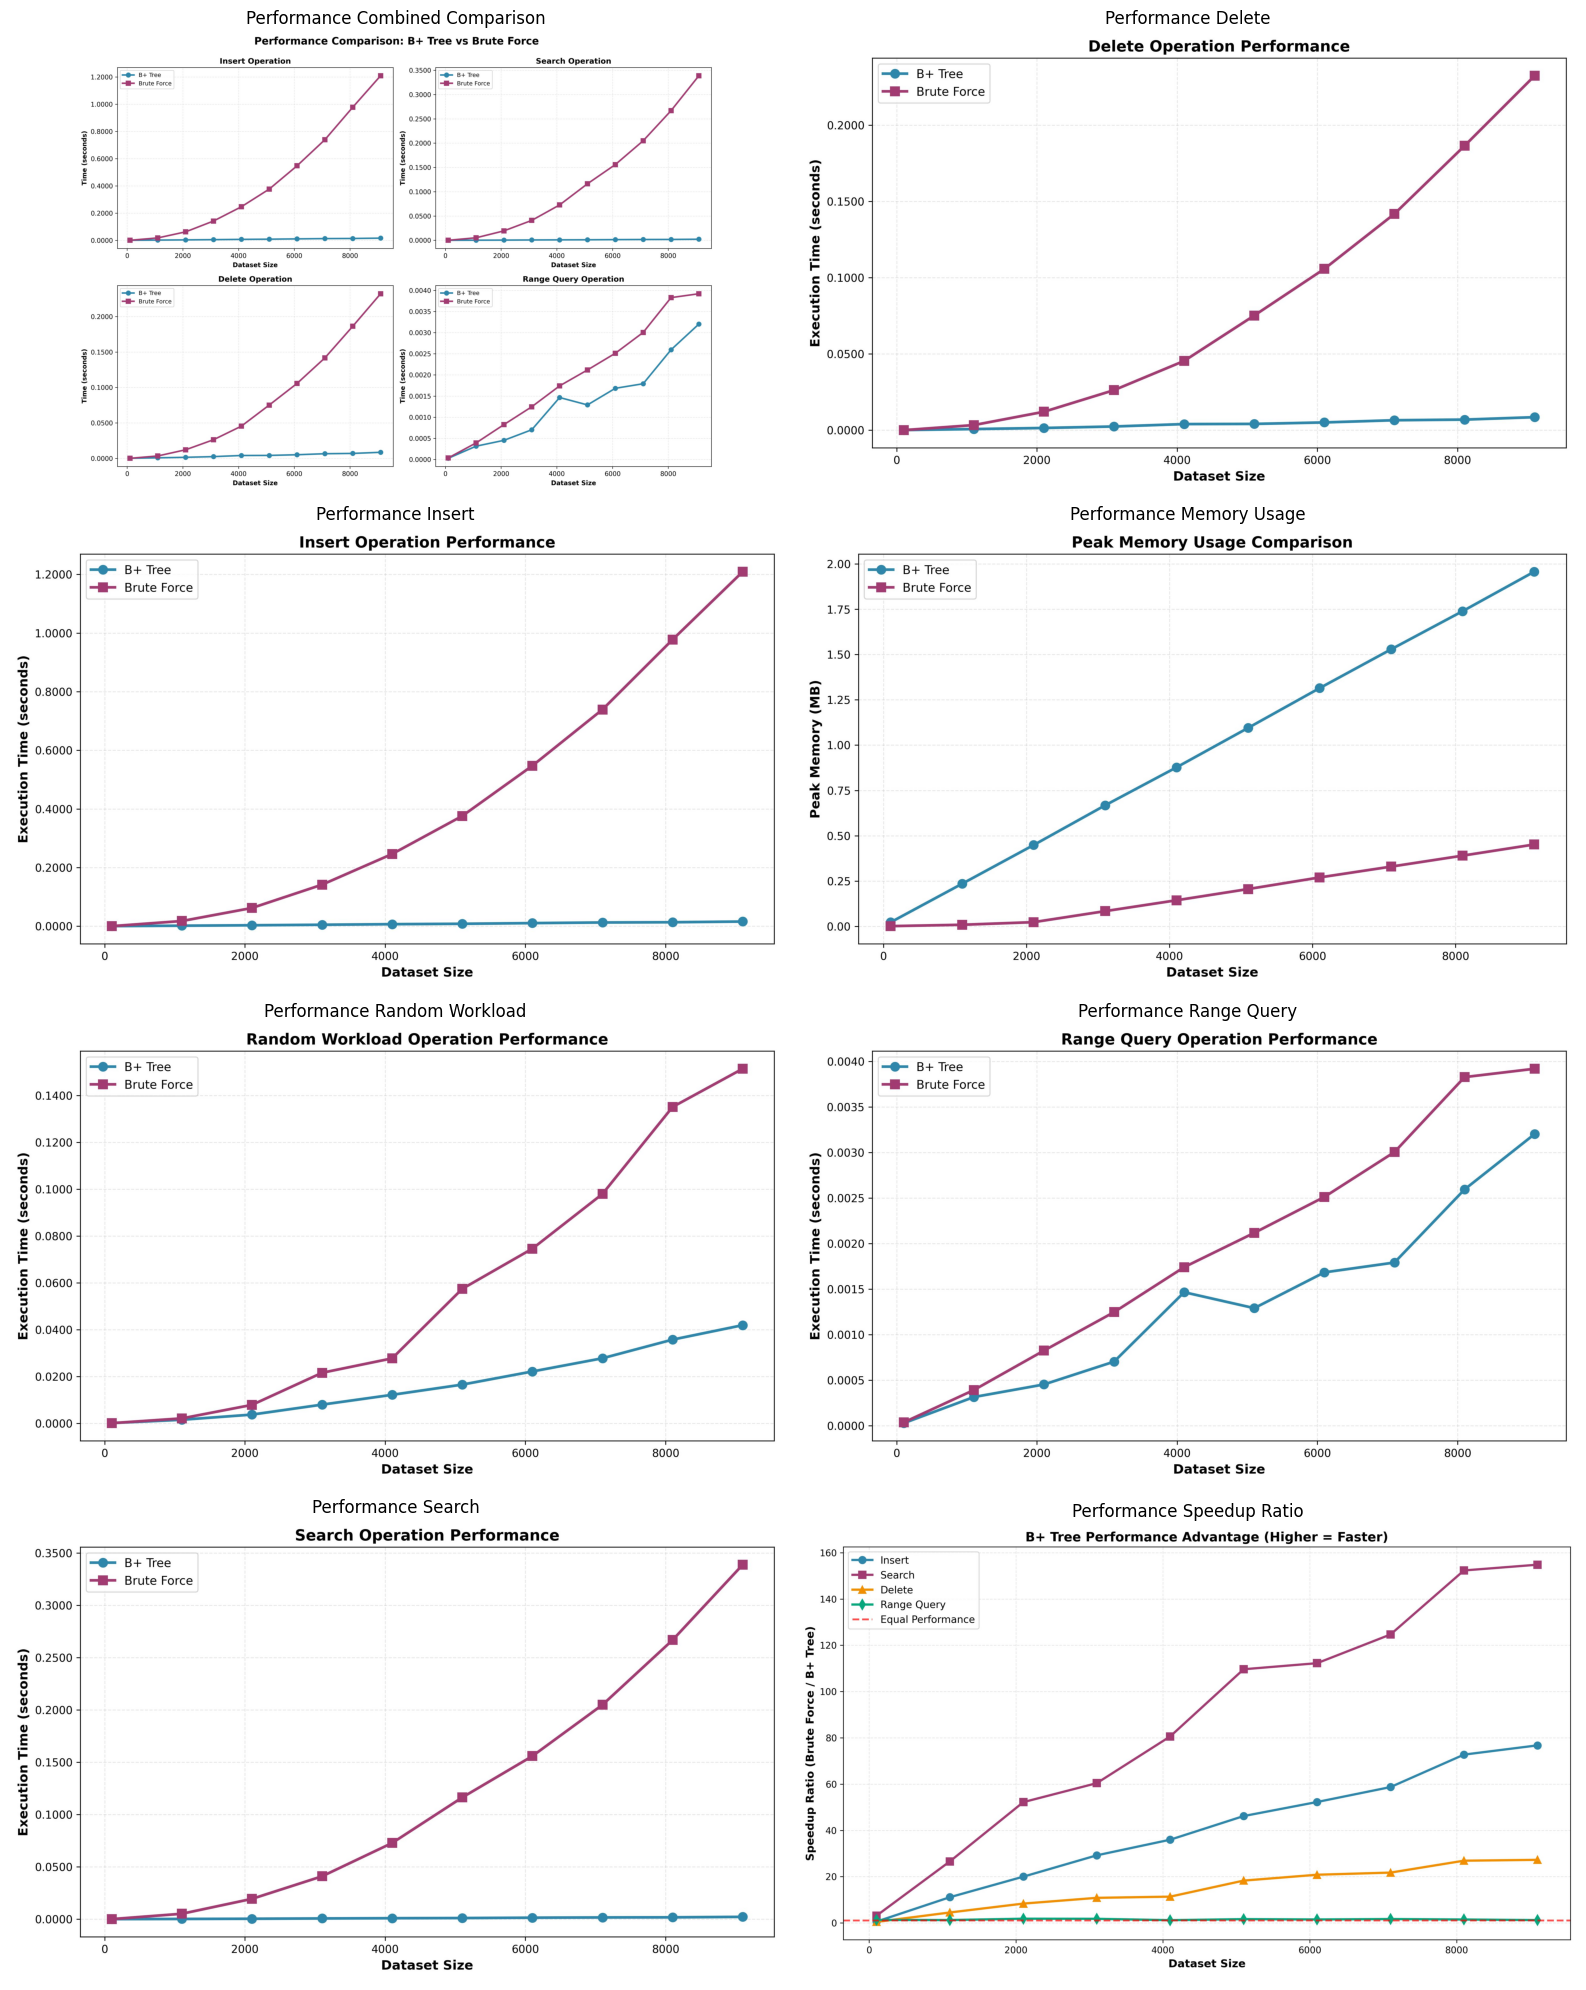

In [4]:
jpg_files = sorted(jpg_dir.glob("performance_*.jpg"))
if not jpg_files:
    display(Markdown("No JPG charts found in `performance_results_jpgs`."))
else:
    display(Markdown("## Performance Charts"))
    cols = 2
    rows = math.ceil(len(jpg_files) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(16, 5 * rows))

    # Normalize axes into a flat list for consistent indexing.
    flat_axes = list(axes.ravel()) if hasattr(axes, "ravel") else [axes]

    for idx, path in enumerate(jpg_files):
        ax = flat_axes[idx]
        img = plt.imread(path)
        ax.imshow(img)
        ax.set_title(path.stem.replace('_', ' ').title())
        ax.axis('off')

    for idx in range(len(jpg_files), len(flat_axes)):
        flat_axes[idx].axis('off')

    plt.tight_layout()
    plt.show()